In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyomo.environ import ConcreteModel, Set, Param, Var, Objective, Constraint, SolverFactory, NonNegativeReals, minimize, Reals, Binary, value



## Get Data

In [34]:
np.random.seed(40)  # Use any number you want

#get fixed data
def get_fixed_data():
    """
    Returns the fixed data for the energy hub simulation.
    """
    num_timeslots = 24
    return {
        # Conversion efficiencies
        'conversion_p2h': 0.9,
        'conversion_h2p': 0.8,

        # Hydrogen storage capacity
        'hydrogen_capacity': 15,
        
        'p2h_max_rate': 5,
        'h2p_max_rate': 5,

        # Electrolyzer cost
        'electrolyzer_cost': 1, 

        # Wind model parameters
        'target_mean_wind': 4.5,
        'wind_reversion_strength': 0.15,
        'extreme_event_prob_wind': 0.03,

        # Price model parameters
        'mean_price': 35,
        'price_reversion_strength': 0.12,
        'wind_influence_on_price': -0.6,
        'price_cap': 90,  
        'price_floor': 0,
        
        
        'num_timeslots': num_timeslots,
        'demand_schedule': [5 + 2 * np.sin(2 * np.pi * t / 24) for t in range(num_timeslots)]

        
    }

data = get_fixed_data()

def price_model(current_price, previous_price, projected_wind, data):
    """
    Price process with dependence on previous prices and projected wind generation.

    Args:
        current_price (float): Current electricity price.
        previous_price (float): Electricity price at the previous time step.
        projected_wind (float): Projected wind generation for the next time step.
        data (dict): Fixed data containing model parameters.

    Returns:
        float: Next price.
    """
    mean_price = data['mean_price']
    reversion_strength = data['price_reversion_strength']
    wind_influence = data['wind_influence_on_price']
    price_cap = data['price_cap']
    price_floor = data['price_floor']

    mean_reversion = reversion_strength * (mean_price - current_price)
    wind_effect = wind_influence * projected_wind
    noise = np.random.normal(0, 1)

    next_price = current_price + 0.6 * (current_price - previous_price) + mean_reversion + wind_effect + noise

    if next_price < 0:
        if np.random.rand() > 0.2:
            next_price = np.random.uniform(0, mean_price * 0.3)

    return max(min(next_price, price_cap), price_floor)

def wind_model(current_wind, data):
    """
    Wind generation process with mean reversion and extreme events.

    Args:
        current_wind (float): Current wind generation.
        data (dict): Fixed data containing model parameters.

    Returns:
        float: Next wind generation.
    """
    target_mean = data['target_mean_wind']
    reversion_strength = data['wind_reversion_strength']
    extreme_event_prob = data['extreme_event_prob_wind']

    mean_reversion = reversion_strength * (target_mean - current_wind)
    noise = np.random.normal(0, 1)

    next_wind = current_wind + mean_reversion + noise

    if np.random.rand() < extreme_event_prob:
        next_wind += np.random.uniform(10, 20)

    return max(next_wind, 0)

def simulate_energy_hub(data, num_steps=100):
    """
    Simulates the energy hub over a specified number of time steps.

    Args:
        data (dict): Fixed data containing model parameters.
        num_steps (int): Number of time steps to simulate.

    Returns:
        pd.DataFrame: DataFrame containing the simulation results.
    """
    results = {
        'time': [],
        'price': [],
        'wind_generation': [],
        'demand': []
    }

    current_price = data['mean_price']
    previous_price = current_price
    current_wind = data['target_mean_wind']

    for t in range(num_steps):
        projected_wind = wind_model(current_wind, data)
        next_price = price_model(current_price, previous_price, projected_wind, data)

        results['time'].append(t)
        results['price'].append(next_price)
        results['wind_generation'].append(projected_wind)
        results['demand'].append(data['demand_schedule'][t % data['num_timeslots']])

        previous_price = current_price
        current_price = next_price
        current_wind = projected_wind

    return pd.DataFrame(results)

# Run the simulation
#simulation_results = simulate_energy_hub(data, num_steps=100)
#print(simulation_results.head())


## Look-ahead policy

In [35]:
class EnergySystemValidator:
    def __init__(self, p2h_max, h2p_max, r_h2p_efficiency):
        self.p2h_max = p2h_max
        self.h2p_max = h2p_max
        self.r_h2p = r_h2p_efficiency

    @staticmethod
    def check_feasibility(state, decision, demand, data):
        """
        Returns (is_valid, error_message)
        """
        p2h_max = data['p2h_max_rate']
        h2p_max = data['h2p_max_rate']
        r_h2p = data['conversion_h2p']
        
        # 1. Capacity Checks
        if decision['p_p2h'] > p2h_max:
            return False, "Exceeds P2H capacity"
        
        if decision['h_h2p'] > h2p_max:
            return False, "Exceeds H2P capacity"

        # 2. Grid Balancing Check
        # The grid must balance the wind, demand, and hydrogen conversions
        expected_grid = (demand + decision['p_p2h'] - 
                         state['p_wind'] - (r_h2p * decision['h_h2p']))
        expected_grid = max(0, expected_grid)  # Grid cannot be negative (no selling back in this model)
        
        if abs(decision['p_grid'] - expected_grid) > 1e-6:
            return False, f"Power imbalance: Grid={decision['p_grid']}, Expected={expected_grid}"

        # 3. Binary and Switching Logic
        y_act, y_de = decision['y_act'], decision['y_de']
        
        if y_act not in [0, 1] or y_de not in [0, 1]:
            return False, "Activation signals must be 0 or 1"
            
        if (y_act * y_de) != 0:
            return False, "Cannot activate and deactivate at the same time"

        return True, "Valid"
    
    @staticmethod
    def get_dummy_action(state, demand, params):

        
    #"""
    #Creates a safe, 'do-nothing' feasible action when the policy fails.
    # This ensures the simulation can continue without crashing.
    #"""
    # 1. Default to no hydrogen conversion
        p_p2h_dummy = 0.0
        h_h2p_dummy = 0.0
    
    # 2. Binary signals: Stay in current state (no activation or deactivation)
        y_act_dummy = 0
        y_de_dummy = 0
    
    # 3. Force Grid Balance
    # Following the equation: p_grid = D_t + p_p2h - p_wind - (R_h2p * h_h2p)
    # With dummy hydrogen values at 0, the grid simply covers net demand
        p_grid_dummy = demand - state['p_wind']
        p_grid_dummy = max(0, p_grid_dummy)  # Ensure grid is not negative
    
        return {
        'p_p2h': p_p2h_dummy,
        'h_h2p': h_h2p_dummy,
        'p_grid': p_grid_dummy,
        'y_act': y_act_dummy,
        'y_de': y_de_dummy
    }

    def decision_to_dict(self, decision):
        return {
            'p_p2h': decision['p_p2h'],
            'h_h2p': decision['h_h2p'],
            'p_grid': decision['p_grid'],
            'y_act': decision['y_act'],
            'y_de': decision['y_de']
        }
    
    @staticmethod
    def cost_function(decision, price):
        """
        Calculates the cost of a given decision based on the current price and parameters.
        """
        # Cost from grid consumption
        grid_cost = decision['p_grid'] * price

        
        return grid_cost
    
    @staticmethod
    def apply_dynamics(state, u, data):
        """
        Applies the transition dynamics to move from state t to state t+1.
        
        Args:
            state (dict): Current state variables {h, y, p_wind, lambda_grid, ...}
            u (dict): Decisions made at time t {p_p2h, h_h2p, y_act, y_de}
            data (dict): Parameters including efficiencies and model constants
            
        Returns:
            dict: The updated state for the next time step (t+1)
        """
        next_state = {}
        
        # 1. Hydrogen Storage Transition: h_{t+1} = h_t + (p_p2h * R_p2h) - h_h2p
        # R_p2h is the 'conversion_p2h' (0.9) from your fixed data
        next_state['h'] = state['h'] + (u['p_p2h'] * data['conversion_p2h']) - u['h_h2p']
        
        # 2. System Status Transition: y_{t+1} = y_t + y_act - y_de
        next_state['y'] = state['y'] + u['y_act'] - u['y_de']
        
        # 3. Store current values as 'previous' for the next step's stochastic models
        next_state['p_wind_prev'] = state['p_wind']
        next_state['lambda_grid_prev'] = state['lambda_grid']
        
        # 4. Stochastic Wind Transition: p_{t+1} ~ P(.|p_t)
        # Uses your wind_model with mean reversion and extreme event logic
        next_state['p_wind'] = wind_model(state['p_wind'], data)
        #print(f"Next wind power: {next_state['p_wind']}")
        
        # 5. Stochastic Price Transition: lambda_{t+1} ~ P(.|lambda_t, lambda_prev, wind_next)
        # Uses your price_model which depends on the newly sampled wind
        next_state['lambda_grid'] = price_model(
            current_price=state['lambda_grid'],
            previous_price=state['lambda_grid_prev'],
            projected_wind=next_state['p_wind'],
            #previous_wind=next_state['p_wind_prev'],
            data=data
        )
        
        return next_state
    
    @staticmethod
    def hierarchical_policy(state, demand):
        """
        Policy Priorities:
        1. Wind Power (First)
        2. Hydrogen Storage (Excess wind -> P2H | Deficit -> H2P)
        3. Grid (Last resort for deficits)
        """
        # Parameters from fixed data
        h_max = data['hydrogen_capacity']
        p2h_limit = data['p2h_max_rate']
        h2p_limit = data['h2p_max_rate']
        r_p2h = data['conversion_p2h']
        r_h2p = data['conversion_h2p']

        
        # Initialize decisions
        p_p2h = 0.0
        h_h2p = 0.0
        y_act = 0
        y_de = 0

        # Step 1: Calculate the immediate balance after Wind
        # surplus > 0 means we have extra energy; surplus < 0 means we have a deficit
        surplus = state['p_wind'] - demand

        if surplus > 0:
            # --- CASE A: EXCESS WIND ---
            # Calculate how much hydrogen the tank can still hold
            room_in_tank = h_max - state['h']
            
            # Max power we can convert is limited by room in tank AND machine capacity
            # We need to divide room_in_tank by r_p2h to see how much POWER can be absorbed
            #p_p2h = min(surplus, p2h_limit, room_in_tank / r_p2h)
            p_p2h = min(float(surplus), p2h_limit, float(room_in_tank / r_p2h))
            
        elif surplus < 0:
            # --- CASE B: ENERGY DEFICIT ---
            deficit = abs(surplus)
            
            # Try to meet the deficit with Hydrogen-to-Power
            # Limited by available hydrogen AND machine capacity
            # We can produce r_h2p units of power for every 1 unit of hydrogen
            max_h2p_output = min(state['h'] * r_h2p, h2p_limit * r_h2p)
            
            # Power provided by hydrogen (cannot exceed the deficit)
            p_from_h2p = min(deficit, max_h2p_output)
            
            # Convert power back to hydrogen units for the decision dictionary
            h_h2p = p_from_h2p / r_h2p

        # Step 3: Grid Balance
        # The Grid must cover exactly what Wind and H2P couldn't meet, 
        # plus any Power-to-Hydrogen consumption we chose to do.
        # Formula: p_grid = Demand + p_p2h - Wind - (r_h2p * h_h2p)
        p_grid = demand + p_p2h - state['p_wind'] - (r_h2p * h_h2p)
        p_grid = max(0, p_grid)  # Grid cannot be negative (no selling back in this model)
        
        # Final check: p_grid should not be negative in this specific hierarchy
        p_grid = max(0, p_grid)

        return {
            'p_p2h': p_p2h,
            'h_h2p': h_h2p,
            'p_grid': p_grid,
            'y_act': y_act,
            'y_de': y_de
        }
    

In [36]:
# Store results for plotting
results = {
    'timestep': [],
    'p_p2h': [],
    'h_h2p': [],
    'p_grid': [],
    'cost': [],
    'hydrogen_level': [],
    'wind': [],
    'demand': [],
    'price': []
}

for t in range(1, 24):
    init_state = {
        'h': 5.0,  # Initial hydrogen storage level
        'y': 0,    # Initial system status (inactive)
        'p_wind': 4.0,  # Initial wind generation
        'lambda_grid': 30.0,  # Initial electricity price
        'p_wind_prev': 4.0,  # Previous wind generation
        'lambda_grid_prev': 30.0  # Previous electricity price
    
    }

    if t == 1:
        policy = EnergySystemValidator.hierarchical_policy(init_state, data['demand_schedule'][t])
        #dummy_decision = EnergySystemValidator.get_dummy_action(init_state, data['demand_schedule'][t], data)
        state = EnergySystemValidator.apply_dynamics(init_state, policy, data)
        decision = EnergySystemValidator.hierarchical_policy(state, data['demand_schedule'][t])
        is_feasible, error_message = EnergySystemValidator.check_feasibility(state, decision, data['demand_schedule'][t],data)
        if not is_feasible:
            print(f"Policy infeasible at time {t}, using dummy action.")
            print(f"Error: {error_message}")
            decision = EnergySystemValidator.get_dummy_action(state, data['demand_schedule'][t], data)
        cost = EnergySystemValidator.cost_function(decision, state['lambda_grid'])
        next_state = EnergySystemValidator.apply_dynamics(state, decision, data) 
    else: 
        state = next_state
        decision = EnergySystemValidator.hierarchical_policy(state, data['demand_schedule'][t])
        is_feasible, error_message = EnergySystemValidator.check_feasibility(state, decision, data['demand_schedule'][t],data)
        if not is_feasible:
            print(f"Policy infeasible at time {t}, using dummy action.")
            print(f"Error: {error_message}")
            decision = EnergySystemValidator.get_dummy_action(state, data['demand_schedule'][t], data)
        cost = EnergySystemValidator.cost_function(decision, state['lambda_grid'])
        next_state = EnergySystemValidator.apply_dynamics(state, decision, data)
    
    # Store results
    results['timestep'].append(t)
    results['p_p2h'].append(decision['p_p2h'])
    results['h_h2p'].append(decision['h_h2p'])
    results['p_grid'].append(decision['p_grid'])
    results['cost'].append(cost)
    results['hydrogen_level'].append(state['h'])
    results['wind'].append(state['p_wind'])
    results['demand'].append(data['demand_schedule'][t])
    results['price'].append(state['lambda_grid'])
    
    print(f"Time step {t}:")
    print(f"cost: {cost:.2f}, wind: {state['p_wind']:.2f}, price: {state['lambda_grid']:.2f}, hydrogen level: {state['h']:.2f}")
    print(f"demand: {data['demand_schedule'][t]}")
    



Time step 1:
cost: 0.00, wind: 3.47, price: 28.39, hydrogen level: 3.10
demand: 5.5176380902050415
Time step 2:
cost: 57.86, wind: 3.21, price: 24.52, hydrogen level: 0.54
demand: 6.0
Time step 3:
cost: 14.77, wind: 5.69, price: 20.53, hydrogen level: 0.00
demand: 6.414213562373095
Time step 4:
cost: 0.00, wind: 6.74, price: 16.22, hydrogen level: 0.00
demand: 6.732050807568877
Time step 5:
cost: 19.19, wind: 5.39, price: 12.52, hydrogen level: 0.01
demand: 6.931851652578136
Time step 6:
cost: 21.92, wind: 4.74, price: 9.68, hydrogen level: 0.00
demand: 7.0
Time step 7:
cost: 15.75, wind: 4.99, price: 8.13, hydrogen level: 0.00
demand: 6.931851652578136
Time step 8:
cost: 0.00, wind: 7.23, price: 6.23, hydrogen level: 0.00
demand: 6.732050807568878
Time step 9:
cost: 0.00, wind: 8.37, price: 3.20, hydrogen level: 0.45
demand: 6.414213562373095
Time step 10:
cost: 0.00, wind: 5.86, price: 2.14, hydrogen level: 2.22
demand: 6.0
Time step 11:
cost: 0.00, wind: 4.32, price: 3.06, hydrogen 

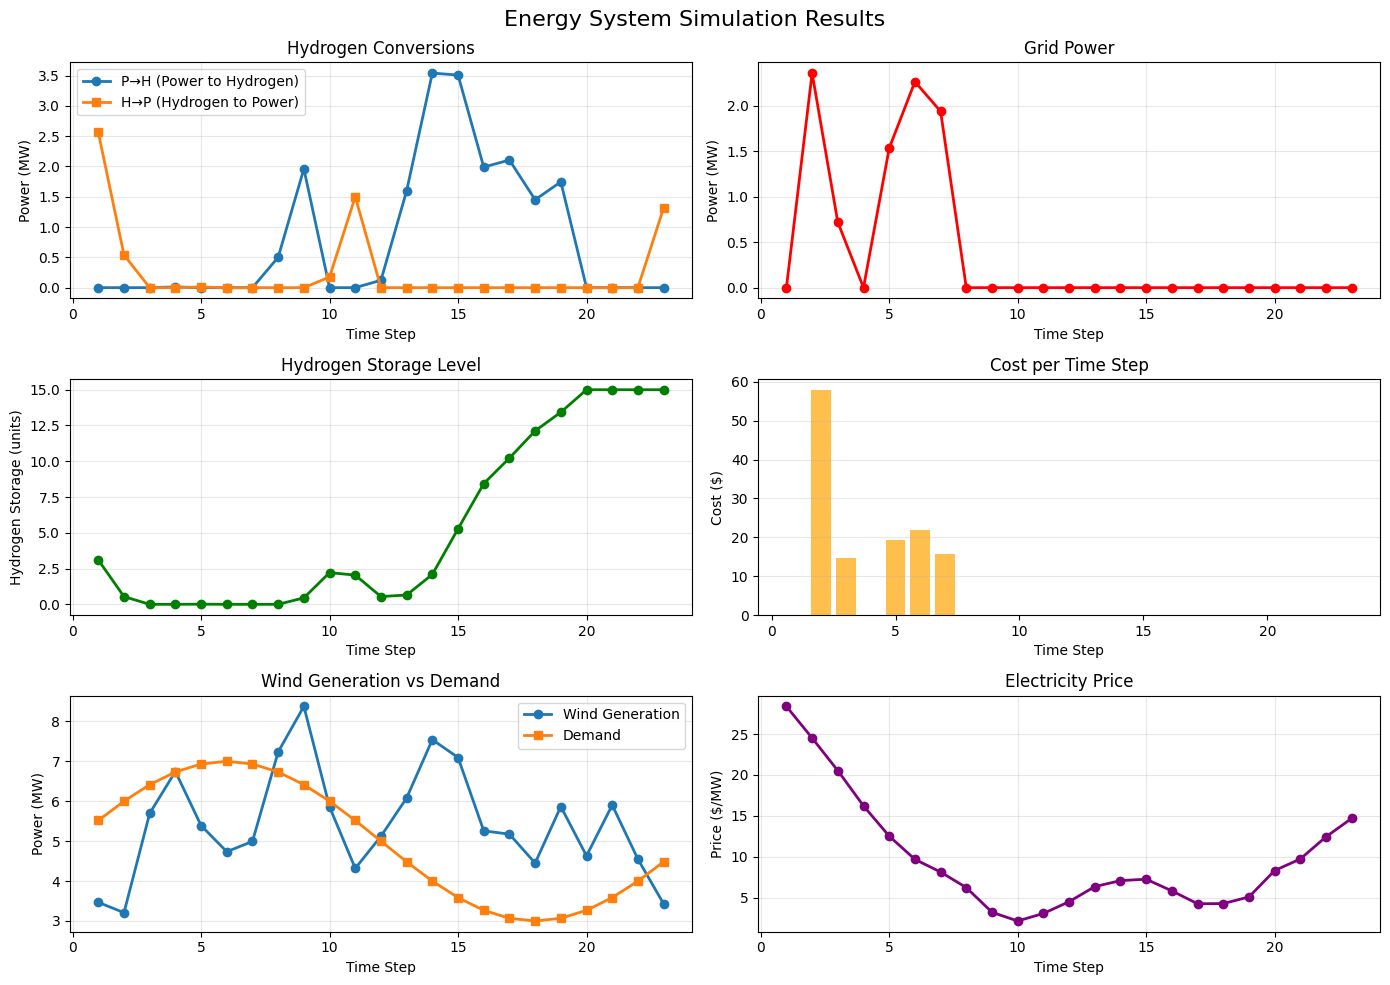


=== SUMMARY STATISTICS ===
Total Cost: $129.49
Average Cost per Time Step: $5.63
Average Grid Power: 0.38 MW
Average Hydrogen Level: 5.27 units
Max Hydrogen Level: 15.00 units
Min Hydrogen Level: 0.00 units


In [37]:
import matplotlib.pyplot as plt

# Create a figure with subplots
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('Energy System Simulation Results', fontsize=16)

# Plot 1: Power to Hydrogen and Hydrogen to Power
ax = axes[0, 0]
ax.plot(results['timestep'], results['p_p2h'], marker='o', label='P→H (Power to Hydrogen)', linewidth=2)
ax.plot(results['timestep'], results['h_h2p'], marker='s', label='H→P (Hydrogen to Power)', linewidth=2)
ax.set_xlabel('Time Step')
ax.set_ylabel('Power (MW)')
ax.set_title('Hydrogen Conversions')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Grid Power
ax = axes[0, 1]
ax.plot(results['timestep'], results['p_grid'], marker='o', color='red', linewidth=2)
ax.set_xlabel('Time Step')
ax.set_ylabel('Power (MW)')
ax.set_title('Grid Power')
ax.grid(True, alpha=0.3)

# Plot 3: Hydrogen Storage Level
ax = axes[1, 0]
ax.plot(results['timestep'], results['hydrogen_level'], marker='o', color='green', linewidth=2)
ax.set_xlabel('Time Step')
ax.set_ylabel('Hydrogen Storage (units)')
ax.set_title('Hydrogen Storage Level')
ax.grid(True, alpha=0.3)

# Plot 4: Cost per Time Step
ax = axes[1, 1]
ax.bar(results['timestep'], results['cost'], color='orange', alpha=0.7)
ax.set_xlabel('Time Step')
ax.set_ylabel('Cost ($)')
ax.set_title('Cost per Time Step')
ax.grid(True, alpha=0.3, axis='y')

# Plot 5: Wind vs Demand
ax = axes[2, 0]
ax.plot(results['timestep'], results['wind'], marker='o', label='Wind Generation', linewidth=2)
ax.plot(results['timestep'], results['demand'], marker='s', label='Demand', linewidth=2)
ax.set_xlabel('Time Step')
ax.set_ylabel('Power (MW)')
ax.set_title('Wind Generation vs Demand')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 6: Price
ax = axes[2, 1]
ax.plot(results['timestep'], results['price'], marker='o', color='purple', linewidth=2)
ax.set_xlabel('Time Step')
ax.set_ylabel('Price ($/MW)')
ax.set_title('Electricity Price')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== SUMMARY STATISTICS ===")
print(f"Total Cost: ${sum(results['cost']):.2f}")
print(f"Average Cost per Time Step: ${sum(results['cost'])/len(results['cost']):.2f}")
print(f"Average Grid Power: {sum(results['p_grid'])/len(results['p_grid']):.2f} MW")
print(f"Average Hydrogen Level: {sum(results['hydrogen_level'])/len(results['hydrogen_level']):.2f} units")
print(f"Max Hydrogen Level: {max(results['hydrogen_level']):.2f} units")
print(f"Min Hydrogen Level: {min(results['hydrogen_level']):.2f} units")


## Generate joint distribution of Price and Wind

Generated 1000 samples from joint distribution

Wind statistics:
  Mean: 7.107
  Std Dev: 4.728
  Min: 0.000
  Max: 37.605

Price statistics:
  Mean: 9.634
  Std Dev: 6.635
  Min: 0.000
  Max: 32.538

Correlation between Wind and Price: -0.4945


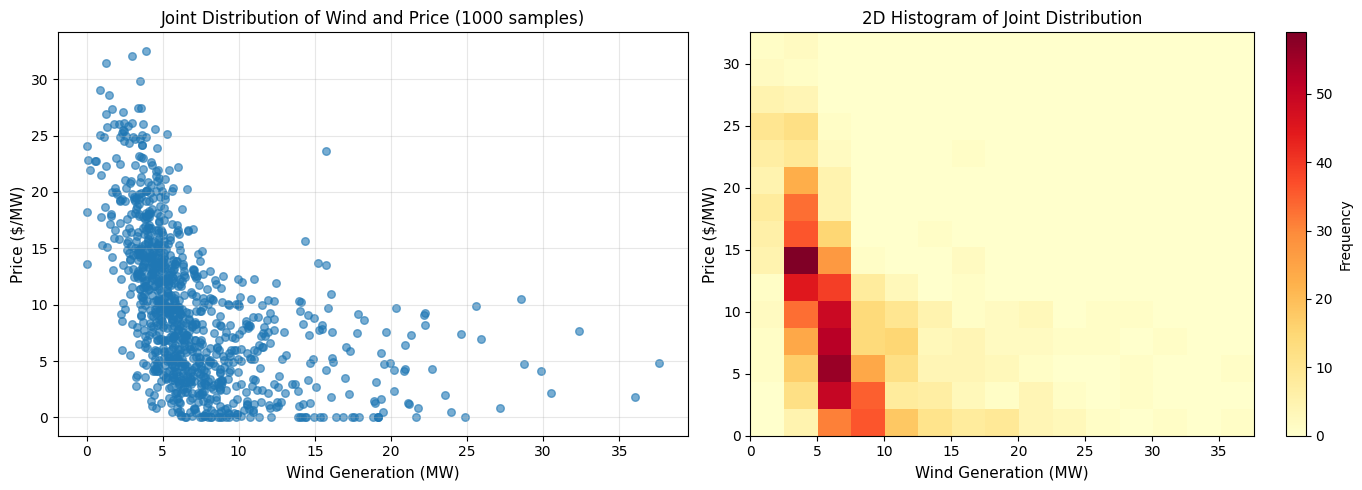


First 10 samples of joint distribution:
       wind      price
0  3.892452  32.538392
1  3.569833  27.442438
2  6.001849  22.179473
3  7.005137  16.751571
4  5.612359  12.183533
5  4.924080   8.749698
6  5.153962   6.856007
7  7.370502   4.822700
8  8.490606   1.818250
9  5.957473   0.869560


In [38]:
# Run wind_model and price_model in a loop 167 times to generate joint distribution
np.random.seed(40)

num_iterations = 1000
wind_values = []
price_values = []

# Initialize starting values
current_wind = data['target_mean_wind']
current_price = data['mean_price']
previous_price = data['mean_price']

# Run the loop
for i in range(num_iterations):
    # Call wind_model to get next wind generation
    current_wind = wind_model(current_wind, data)
    
    # Call price_model to get next price based on current price, previous price, and projected wind
    next_price = price_model(current_price, previous_price, current_wind, data)
    
    # Store the values
    wind_values.append(current_wind)
    price_values.append(next_price)
    
    # Update prices for next iteration
    previous_price = current_price
    current_price = next_price

# Create a DataFrame for the joint distribution
joint_dist_df = pd.DataFrame({
    'wind': wind_values,
    'price': price_values
})

print(f"Generated {num_iterations} samples from joint distribution")
print(f"\nWind statistics:")
print(f"  Mean: {np.mean(wind_values):.3f}")
print(f"  Std Dev: {np.std(wind_values):.3f}")
print(f"  Min: {np.min(wind_values):.3f}")
print(f"  Max: {np.max(wind_values):.3f}")

print(f"\nPrice statistics:")
print(f"  Mean: {np.mean(price_values):.3f}")
print(f"  Std Dev: {np.std(price_values):.3f}")
print(f"  Min: {np.min(price_values):.3f}")
print(f"  Max: {np.max(price_values):.3f}")

print(f"\nCorrelation between Wind and Price: {np.corrcoef(wind_values, price_values)[0,1]:.4f}")

# Visualize the joint distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(wind_values, price_values, alpha=0.6, s=30)
axes[0].set_xlabel('Wind Generation (MW)', fontsize=11)
axes[0].set_ylabel('Price ($/MW)', fontsize=11)
axes[0].set_title(f'Joint Distribution of Wind and Price ({num_iterations} samples)', fontsize=12)
axes[0].grid(True, alpha=0.3)

# 2D histogram / heatmap
axes[1].hist2d(wind_values, price_values, bins=15, cmap='YlOrRd')
axes[1].set_xlabel('Wind Generation (MW)', fontsize=11)
axes[1].set_ylabel('Price ($/MW)', fontsize=11)
axes[1].set_title('2D Histogram of Joint Distribution', fontsize=12)
plt.colorbar(axes[1].collections[0], ax=axes[1], label='Frequency')

plt.tight_layout()
plt.show()

# Display first few rows of the joint distribution
print(f"\nFirst 10 samples of joint distribution:")
print(joint_dist_df.head(10))

K-Means Clustering Results (K=167):
Number of clusters: 167
Inertia (sum of squared distances): 5.92

Cluster Centers (original scale):
Cluster    Wind (MW)       Price ($/MW)   
----------------------------------------
0          0.530           22.596         
1          8.629           5.809          
2          5.576           10.693         
3          25.581          9.885          
4          14.285          1.143          
5          4.020           18.002         
6          5.581           4.328          
7          20.679          4.216          
8          14.416          7.791          
9          6.568           2.681          
10         2.787           13.947         
11         3.704           26.040         
12         30.491          2.169          
13         9.235           0.747          
14         8.587           12.207         
15         4.877           6.827          
16         4.829           20.269         
17         11.653          7.009          
18    

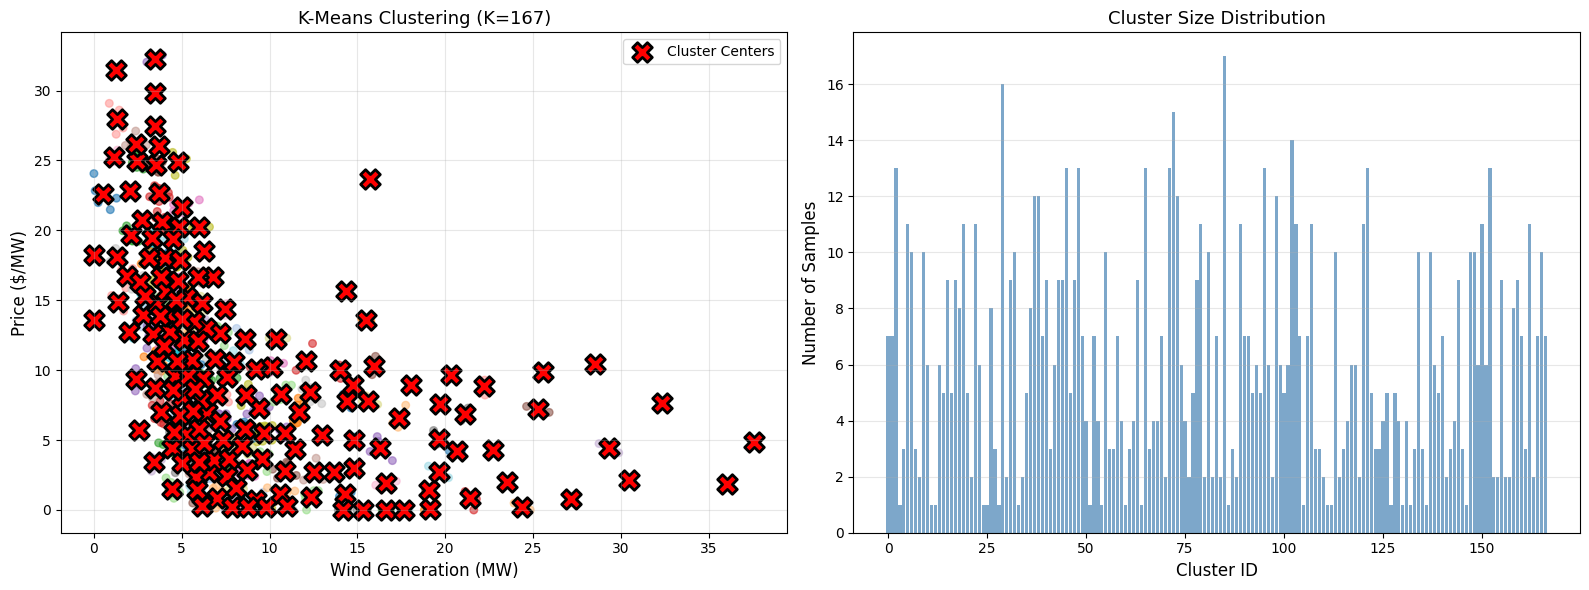



Cluster Statistics:
Cluster    Wind Mean       Price Mean      Wind Std        Price Std      
----------------------------------------------------------------------
0          0.530           22.596          0.468           0.813          
1          8.629           5.809           0.293           0.431          
2          5.576           10.693          0.279           0.358          
3          25.581          9.885           nan             nan            
4          14.285          1.143           0.339           0.154          
5          4.020           18.002          0.171           0.259          
6          5.581           4.328           0.243           0.317          
7          20.679          4.216           0.393           0.079          
8          14.416          7.791           0.308           0.689          
9          6.568           2.681           0.185           0.391          
10         2.787           13.947          0.228           0.549          
11     

In [39]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Standardize the data for k-means clustering
# This ensures both wind and price have equal influence on clustering
scaler = StandardScaler()
scaled_data = scaler.fit_transform(joint_dist_df[['wind', 'price']])

# Perform K-means clustering with K=167
K = 167
kmeans = KMeans(n_clusters=K, random_state=40, n_init=10)
cluster_labels = kmeans.fit_predict(scaled_data)

# Add cluster labels to the DataFrame
joint_dist_df['cluster'] = cluster_labels

# Get cluster centers in original scale
cluster_centers_scaled = kmeans.cluster_centers_
cluster_centers_original = scaler.inverse_transform(cluster_centers_scaled)

print(f"K-Means Clustering Results (K={K}):")
print(f"Number of clusters: {len(np.unique(cluster_labels))}")
print(f"Inertia (sum of squared distances): {kmeans.inertia_:.2f}")
print(f"\nCluster Centers (original scale):")
print(f"{'Cluster':<10} {'Wind (MW)':<15} {'Price ($/MW)':<15}")
print("-" * 40)
for i, center in enumerate(cluster_centers_original):
    print(f"{i:<10} {center[0]:<15.3f} {center[1]:<15.3f}")

# Analyze cluster distribution
print(f"\n\nCluster Distribution:")
print(f"{'Cluster':<10} {'Size':<10} {'Percentage':<15}")
print("-" * 35)
cluster_counts = np.bincount(cluster_labels)
for cluster_id, count in enumerate(cluster_counts):
    percentage = (count / len(cluster_labels)) * 100
    print(f"{cluster_id:<10} {count:<10} {percentage:<15.2f}%")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Clusters with centers
ax = axes[0]
scatter = ax.scatter(joint_dist_df['wind'], joint_dist_df['price'], 
                     c=joint_dist_df['cluster'], cmap='tab20', alpha=0.6, s=30)
ax.scatter(cluster_centers_original[:, 0], cluster_centers_original[:, 1], 
           marker='X', s=200, c='red', edgecolors='black', linewidth=2, label='Cluster Centers')
ax.set_xlabel('Wind Generation (MW)', fontsize=12)
ax.set_ylabel('Price ($/MW)', fontsize=12)
ax.set_title(f'K-Means Clustering (K={K})', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Cluster sizes
ax = axes[1]
cluster_sizes = np.bincount(cluster_labels)
ax.bar(range(len(cluster_sizes)), cluster_sizes, color='steelblue', alpha=0.7)
ax.set_xlabel('Cluster ID', fontsize=12)
ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_title('Cluster Size Distribution', fontsize=13)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Display cluster statistics
print(f"\n\nCluster Statistics:")
print(f"{'Cluster':<10} {'Wind Mean':<15} {'Price Mean':<15} {'Wind Std':<15} {'Price Std':<15}")
print("-" * 70)
for cluster_id in range(K):
    cluster_mask = joint_dist_df['cluster'] == cluster_id
    if cluster_mask.sum() > 0:
        wind_mean = joint_dist_df[cluster_mask]['wind'].mean()
        price_mean = joint_dist_df[cluster_mask]['price'].mean()
        wind_std = joint_dist_df[cluster_mask]['wind'].std()
        price_std = joint_dist_df[cluster_mask]['price'].std()
        print(f"{cluster_id:<10} {wind_mean:<15.3f} {price_mean:<15.3f} {wind_std:<15.3f} {price_std:<15.3f}")


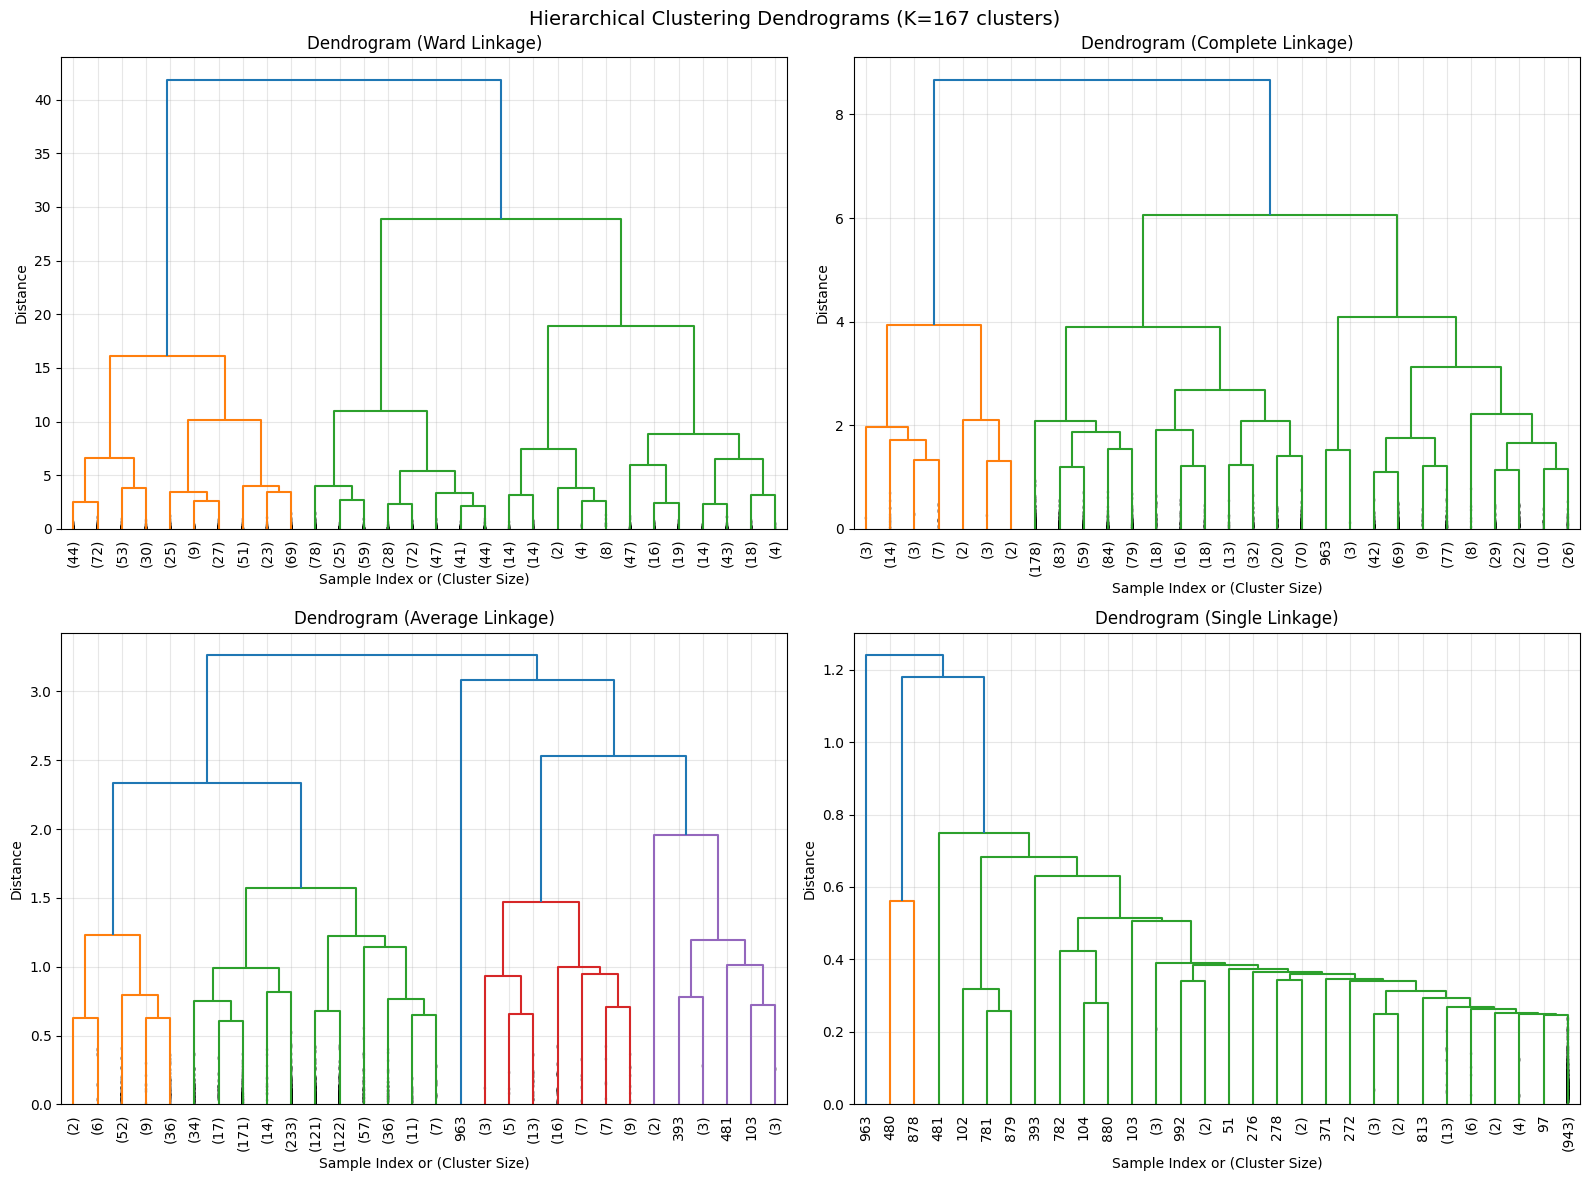

HIERARCHICAL CLUSTERING ANALYSIS (Ward Linkage)

Number of clusters created: 167
Expected clusters: 167


Hierarchical Cluster Distribution:
Cluster    Size       Percentage     
-----------------------------------
0          0          0.00           %
1          10         1.00           %
2          10         1.00           %
3          13         1.30           %
4          11         1.10           %
5          9          0.90           %
6          9          0.90           %
7          12         1.20           %
8          5          0.50           %
9          15         1.50           %
10         5          0.50           %
11         9          0.90           %
12         8          0.80           %
13         3          0.30           %
14         7          0.70           %
15         4          0.40           %
16         14         1.40           %
17         16         1.60           %
18         9          0.90           %
19         6          0.60           %
20   

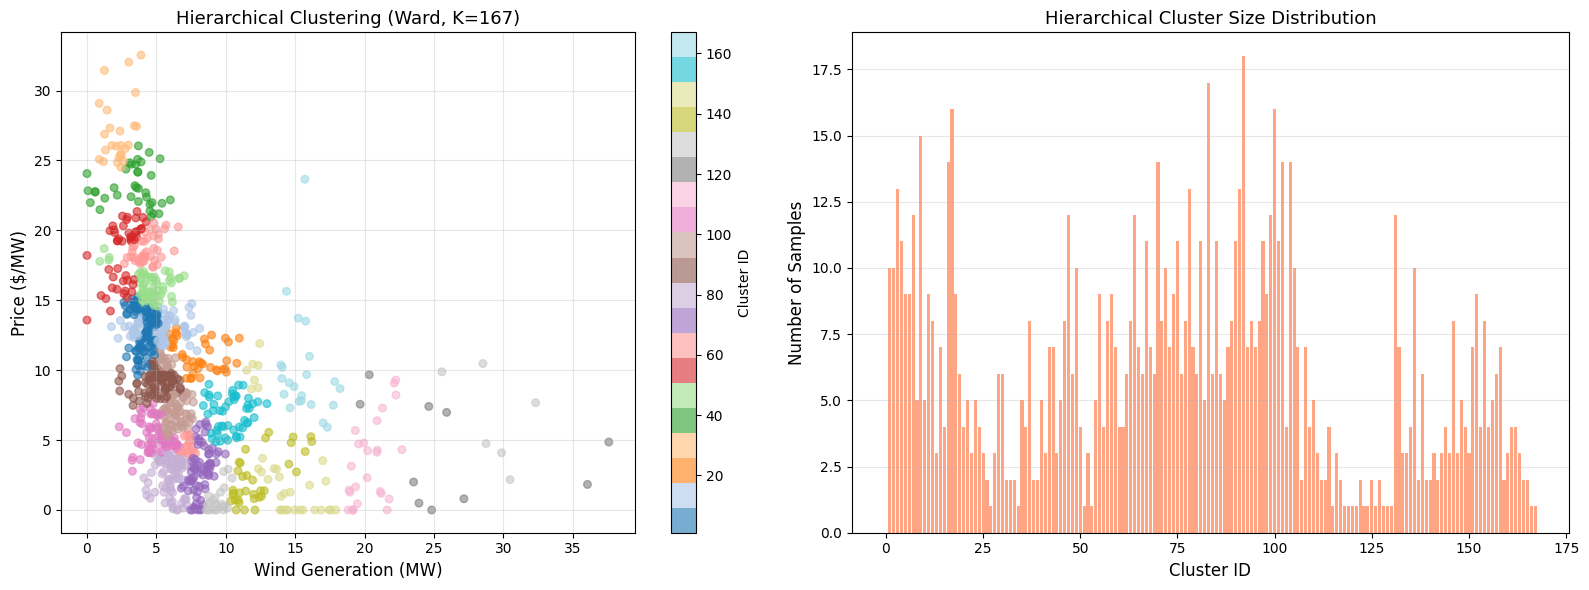



Hierarchical Cluster Statistics (first 20 clusters):
Cluster    Wind Mean       Price Mean      Wind Std        Price Std      
----------------------------------------------------------------------
0          4.366           12.591          0.126           0.248          
1          4.748           11.707          0.187           0.357          
2          3.872           10.557          0.269           0.521          
3          3.624           11.643          0.373           0.359          
4          4.275           14.301          0.180           0.134          
5          4.469           13.517          0.118           0.228          
6          4.977           13.688          0.148           0.376          
7          2.853           14.376          0.158           0.359          
8          3.493           14.595          0.156           0.355          
9          2.431           13.040          0.485           0.462          
10         3.406           12.618          0.155 

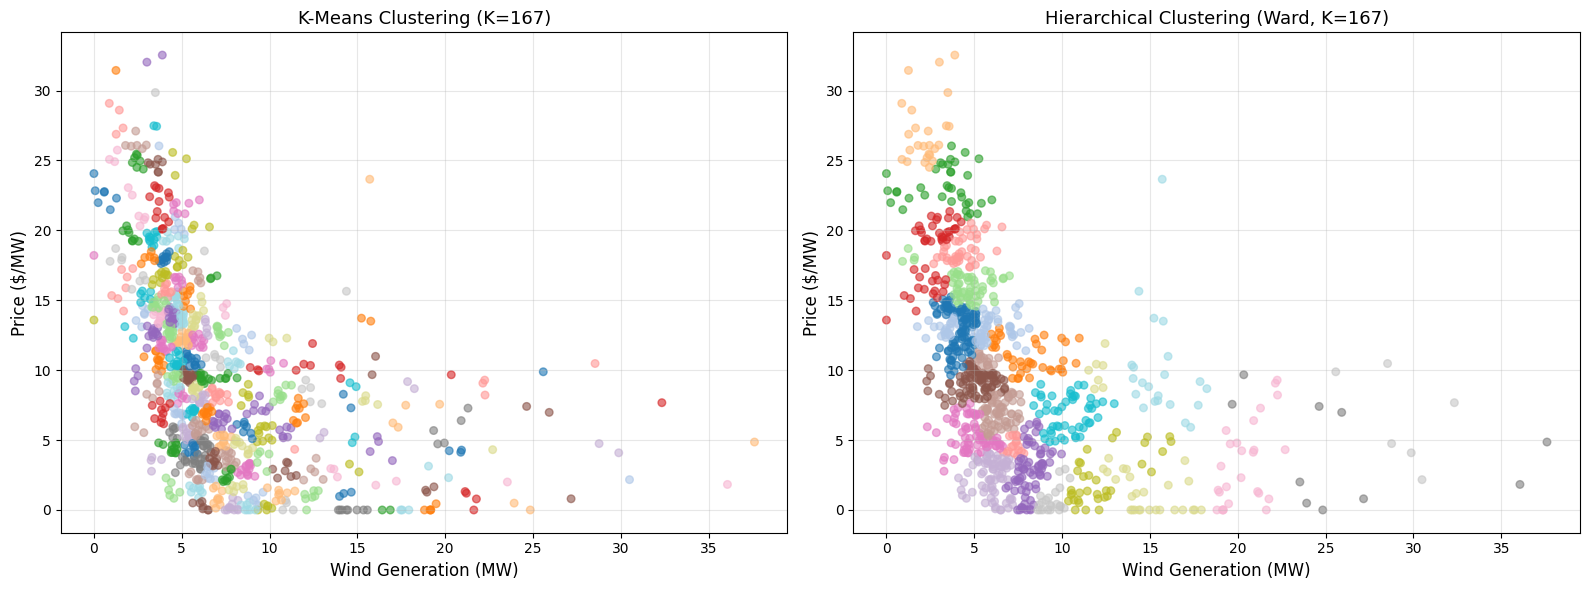


Note: ARI of 0.6442 suggests the two methods produce somewhat different clusterings.


In [40]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist

# Perform Hierarchical Clustering
# Using different linkage methods to compare

linkage_methods = ['ward', 'complete', 'average', 'single']
hierarchical_results = {}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Hierarchical Clustering Dendrograms (K=167 clusters)', fontsize=14)

for idx, method in enumerate(linkage_methods):
    ax = axes[idx // 2, idx % 2]
    
    # Compute linkage matrix
    Z = linkage(scaled_data, method=method)
    
    # Create dendrogram (truncated for visibility)
    dendrogram(Z, ax=ax, truncate_mode='lastp', p=30, 
               leaf_rotation=90, leaf_font_size=10, show_contracted=True)
    
    ax.set_title(f'Dendrogram ({method.capitalize()} Linkage)', fontsize=12)
    ax.set_xlabel('Sample Index or (Cluster Size)')
    ax.set_ylabel('Distance')
    ax.grid(True, alpha=0.3)
    
    # Store linkage matrix for later use
    hierarchical_results[method] = Z

plt.tight_layout()
plt.show()

# Use Ward linkage for detailed analysis (most commonly used)
print("=" * 80)
print("HIERARCHICAL CLUSTERING ANALYSIS (Ward Linkage)")
print("=" * 80)

Z_ward = hierarchical_results['ward']

# Cut dendrogram to create K=167 clusters
K = 167
hierarchical_clusters = fcluster(Z_ward, K, criterion='maxclust')

print(f"\nNumber of clusters created: {len(np.unique(hierarchical_clusters))}")
print(f"Expected clusters: {K}")

# Add cluster labels to DataFrame
joint_dist_df['hierarchical_cluster'] = hierarchical_clusters

# Get cluster information
print(f"\n\nHierarchical Cluster Distribution:")
print(f"{'Cluster':<10} {'Size':<10} {'Percentage':<15}")
print("-" * 35)
hier_cluster_counts = np.bincount(hierarchical_clusters)
for cluster_id, count in enumerate(hier_cluster_counts):
    percentage = (count / len(hierarchical_clusters)) * 100
    print(f"{cluster_id:<10} {count:<10} {percentage:<15.2f}%")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Hierarchical clusters
ax = axes[0]
scatter = ax.scatter(joint_dist_df['wind'], joint_dist_df['price'], 
                     c=joint_dist_df['hierarchical_cluster'], cmap='tab20', alpha=0.6, s=30)
ax.set_xlabel('Wind Generation (MW)', fontsize=12)
ax.set_ylabel('Price ($/MW)', fontsize=12)
ax.set_title(f'Hierarchical Clustering (Ward, K={K})', fontsize=13)
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Cluster ID')

# Plot 2: Cluster size distribution
ax = axes[1]
hier_cluster_sizes = np.bincount(hierarchical_clusters)
ax.bar(range(len(hier_cluster_sizes)), hier_cluster_sizes, color='coral', alpha=0.7)
ax.set_xlabel('Cluster ID', fontsize=12)
ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_title('Hierarchical Cluster Size Distribution', fontsize=13)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Cluster statistics
print(f"\n\nHierarchical Cluster Statistics (first 20 clusters):")
print(f"{'Cluster':<10} {'Wind Mean':<15} {'Price Mean':<15} {'Wind Std':<15} {'Price Std':<15}")
print("-" * 70)
for cluster_id in range(min(20, K)):
    cluster_mask = joint_dist_df['hierarchical_cluster'] == cluster_id + 1
    if cluster_mask.sum() > 0:
        wind_mean = joint_dist_df[cluster_mask]['wind'].mean()
        price_mean = joint_dist_df[cluster_mask]['price'].mean()
        wind_std = joint_dist_df[cluster_mask]['wind'].std()
        price_std = joint_dist_df[cluster_mask]['price'].std()
        count = cluster_mask.sum()
        print(f"{cluster_id:<10} {wind_mean:<15.3f} {price_mean:<15.3f} {wind_std:<15.3f} {price_std:<15.3f}")

# Comparison between K-Means and Hierarchical Clustering
print(f"\n\n{'='*80}")
print("COMPARISON: K-MEANS vs HIERARCHICAL CLUSTERING")
print(f"{'='*80}")

# Calculate cluster overlap
from sklearn.metrics import adjusted_rand_score, silhouette_score

ari = adjusted_rand_score(kmeans.labels_, hierarchical_clusters - 1)
print(f"\nAdjusted Rand Index (ARI): {ari:.4f}")
print(f"  (1.0 = perfect agreement, 0.0 = random labeling)")

# Silhouette scores
silhouette_kmeans = silhouette_score(scaled_data, kmeans.labels_)
silhouette_hierarchical = silhouette_score(scaled_data, hierarchical_clusters - 1)

print(f"\nSilhouette Scores (higher is better):")
print(f"  K-Means:        {silhouette_kmeans:.4f}")
print(f"  Hierarchical:   {silhouette_hierarchical:.4f}")

# Create comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means clusters
ax = axes[0]
scatter1 = ax.scatter(joint_dist_df['wind'], joint_dist_df['price'], 
                      c=kmeans.labels_, cmap='tab20', alpha=0.6, s=30)
ax.set_xlabel('Wind Generation (MW)', fontsize=12)
ax.set_ylabel('Price ($/MW)', fontsize=12)
ax.set_title(f'K-Means Clustering (K=167)', fontsize=13)
ax.grid(True, alpha=0.3)

# Hierarchical clusters
ax = axes[1]
scatter2 = ax.scatter(joint_dist_df['wind'], joint_dist_df['price'], 
                      c=joint_dist_df['hierarchical_cluster'], cmap='tab20', alpha=0.6, s=30)
ax.set_xlabel('Wind Generation (MW)', fontsize=12)
ax.set_ylabel('Price ($/MW)', fontsize=12)
ax.set_title(f'Hierarchical Clustering (Ward, K=167)', fontsize=13)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nNote: ARI of {ari:.4f} suggests the two methods produce {'very similar' if ari > 0.8 else 'somewhat different' if ari > 0.5 else 'quite different'} clusterings.")


In [41]:
# assign probability distribution to each cluster based on frequency
cluster_probabilities = joint_dist_df['cluster'].value_counts(normalize=True).sort_index()



## New policy taking into account uncertainty

In [42]:
class UncertaintyEnergySystemValidator:
    def __init__(self, p2h_max, h2p_max, r_h2p_efficiency):
        self.p2h_max = p2h_max
        self.h2p_max = h2p_max
        self.r_h2p = r_h2p_efficiency

    @staticmethod
    def check_feasibility(state, decision, demand, data):
        """
        Returns (is_valid, error_message)

        Also enforces a non-anticipativity check when `data` contains
        a `decisions_by_scenario` mapping and a list `first_stage_vars`.

        Expected `data` keys for non-anticipativity:
          - `decisions_by_scenario`: dict mapping scenario_id -> decision dict
          - `first_stage_vars`: list of variable names that must be equal across scenarios
        """
        p2h_max = data['p2h_max_rate']
        h2p_max = data['h2p_max_rate']
        r_h2p = data['conversion_h2p']

        # 1. Capacity Checks
        if decision['p_p2h'] > p2h_max:
            return False, "Exceeds P2H capacity"

        if decision['h_h2p'] > h2p_max:
            return False, "Exceeds H2P capacity"

        # 2. Grid Balancing Check
        # The grid must balance the wind, demand, and hydrogen conversions
        expected_grid = (demand + decision['p_p2h'] - 
                         state['p_wind'] - (r_h2p * decision['h_h2p']))
        expected_grid = max(0, expected_grid)  # Grid cannot be negative (no selling back in this model)

        if abs(decision['p_grid'] - expected_grid) > 1e-6:
            return False, f"Power imbalance: Grid={decision['p_grid']}, Expected={expected_grid}"

        # 3. Binary and Switching Logic
        y_act, y_de = decision['y_act'], decision['y_de']

        if y_act not in [0, 1] or y_de not in [0, 1]:
            return False, "Activation signals must be 0 or 1"

        if (y_act * y_de) != 0:
            return False, "Cannot activate and deactivate at the same time"

        # 4. Non-anticipativity check (optional)
        # If the caller provided `decisions_by_scenario` and `first_stage_vars` in `data`,
        # ensure the values for the specified first-stage variables are identical
        # across all scenarios (within a tolerance).
        decisions_by_scenario = data.get('decisions_by_scenario')
        first_stage_vars = data.get('first_stage_vars')

        if decisions_by_scenario is not None and first_stage_vars is not None:
            tol = data.get('non_anticipativity_tolerance', 1e-6)
            # Compare the current decision against each scenario's decision
            for var in first_stage_vars:
                # Value in the current `decision` (the one being checked)
                ref_val = decision.get(var)
                for scen_id, scen_dec in decisions_by_scenario.items():
                    # If scenario decision missing the var, treat as mismatch
                    if var not in scen_dec:
                        return False, f"Non-anticipativity violation: variable '{var}' missing in scenario {scen_id}"
                    if ref_val is None:
                        # If current decision lacks the var but scenario has it -> violation
                        if scen_dec.get(var) is not None:
                            return False, f"Non-anticipativity violation for '{var}': inconsistent presence across scenarios"
                        else:
                            continue
                    # Numerical comparison
                    try:
                        if abs(float(scen_dec.get(var)) - float(ref_val)) > tol:
                            return False, f"Non-anticipativity violated for variable '{var}': scenario {scen_id} value differs"
                    except Exception:
                        # Fallback to direct comparison for non-numeric values
                        if scen_dec.get(var) != ref_val:
                            return False, f"Non-anticipativity violated for variable '{var}': scenario {scen_id} value differs"

        return True, "Valid"

    @staticmethod
    def get_dummy_action(state, demand, params):
        # Creates a safe, 'do-nothing' feasible action when the policy fails.
        # This ensures the simulation can continue without crashing.
        p_p2h_dummy = 0.0
        h_h2p_dummy = 0.0

        # Binary signals: Stay in current state (no activation or deactivation)
        y_act_dummy = 0
        y_de_dummy = 0

        # Force Grid Balance
        p_grid_dummy = demand - state['p_wind']
        p_grid_dummy = max(0, p_grid_dummy)  # Ensure grid is not negative

        return {
            'p_p2h': p_p2h_dummy,
            'h_h2p': h_h2p_dummy,
            'p_grid': p_grid_dummy,
            'y_act': y_act_dummy,
            'y_de': y_de_dummy
        }

    def decision_to_dict(self, decision):
        return {
            'p_p2h': decision['p_p2h'],
            'h_h2p': decision['h_h2p'],
            'p_grid': decision['p_grid'],
            'y_act': decision['y_act'],
            'y_de': decision['y_de']
        }

    @staticmethod
    def cost_function(decision, price, cluster_probabilities=None, w=None):
        """
        Calculates the cost of a given decision based on the current price and parameters.
        If `cluster_probabilities` and `w` (scenario id) are provided, the function can
        return the weighted contribution of this decision to the expected cost.
        """
        grid_cost = decision['p_grid'] * price
        if cluster_probabilities is not None and w is not None:
            prob = cluster_probabilities.get(w, 0)
            return prob * grid_cost
        return grid_cost

    @staticmethod
    def apply_dynamics(state, u, data):
        """
        Applies the transition dynamics to move from state t to state t+1.

        Args:
            state (dict): Current state variables {h, y, p_wind, lambda_grid, ...}
            u (dict): Decisions made at time t {p_p2h, h_h2p, y_act, y_de}
            data (dict): Parameters including efficiencies and model constants

        Returns:
            dict: The updated state for the next time step (t+1)
        """
        next_state = {}

        # 1. Hydrogen Storage Transition: h_{t+1} = h_t + (p_p2h * R_p2h) - h_h2p
        next_state['h'] = state['h'] + (u['p_p2h'] * data['conversion_p2h']) - u['h_h2p']

        # 2. System Status Transition: y_{t+1} = y_t + y_act - y_de
        next_state['y'] = state['y'] + u['y_act'] - u['y_de']

        # 3. Store current values as 'previous' for the next step's stochastic models
        next_state['p_wind_prev'] = state['p_wind']
        next_state['lambda_grid_prev'] = state['lambda_grid']

        # 4. Stochastic Wind Transition: p_{t+1} ~ P(.|p_t)
        next_state['p_wind'] = wind_model(state['p_wind'], data)

        # 5. Stochastic Price Transition: lambda_{t+1} ~ P(.|lambda_t, lambda_prev, wind_next)
        next_state['lambda_grid'] = price_model(
            current_price=state['lambda_grid'],
            previous_price=state['lambda_grid_prev'],
            projected_wind=next_state['p_wind'],
            data=data
        )

        return next_state

    @staticmethod
    def hierarchical_policy(state, demand):
        """
        Policy Priorities:
        1. Wind Power (First)
        2. Hydrogen Storage (Excess wind -> P2H | Deficit -> H2P)
        3. Grid (Last resort for deficits)
        """
        # Parameters from fixed data
        h_max = data['hydrogen_capacity']
        p2h_limit = data['p2h_max_rate']
        h2p_limit = data['h2p_max_rate']
        r_p2h = data['conversion_p2h']
        r_h2p = data['conversion_h2p']

        # Initialize decisions
        p_p2h = 0.0
        h_h2p = 0.0
        y_act = 0
        y_de = 0

        # Step 1: Calculate the immediate balance after Wind
        surplus = state['p_wind'] - demand

        if surplus > 0:
            room_in_tank = h_max - state['h']
            p_p2h = min(float(surplus), p2h_limit, float(room_in_tank / r_p2h))
        elif surplus < 0:
            deficit = abs(surplus)
            max_h2p_output = min(state['h'] * r_h2p, h2p_limit * r_h2p)
            p_from_h2p = min(deficit, max_h2p_output)
            h_h2p = p_from_h2p / r_h2p

        p_grid = demand + p_p2h - state['p_wind'] - (r_h2p * h_h2p)
        p_grid = max(0, p_grid)

        return {
            'p_p2h': p_p2h,
            'h_h2p': h_h2p,
            'p_grid': p_grid,
            'y_act': y_act,
            'y_de': y_de
        }


In [43]:
# Store results for plotting
results = {
    'timestep': [],
    'p_p2h': [],
    'h_h2p': [],
    'p_grid': [],
    'cost': [],
    'hydrogen_level': [],
    'wind': [],
    'demand': [],
    'price': []
}

for t in range(1, 24):
    init_state = {
        'h': 5.0,  # Initial hydrogen storage level
        'y': 0,    # Initial system status (inactive)
        'p_wind': 4.0,  # Initial wind generation
        'lambda_grid': 30.0,  # Initial electricity price
        'p_wind_prev': 4.0,  # Previous wind generation
        'lambda_grid_prev': 30.0  # Previous electricity price
    
    }

    if t == 1:
        policy = UncertaintyEnergySystemValidator.hierarchical_policy(init_state, data['demand_schedule'][t])
        #dummy_decision = EnergySystemValidator.get_dummy_action(init_state, data['demand_schedule'][t], data)
        state = UncertaintyEnergySystemValidator.apply_dynamics(init_state, policy, data)
        decision = UncertaintyEnergySystemValidator.hierarchical_policy(state, data['demand_schedule'][t])
        is_feasible, error_message = UncertaintyEnergySystemValidator.check_feasibility(state, decision, data['demand_schedule'][t],data)
        if not is_feasible:
            print(f"Policy infeasible at time {t}, using dummy action.")
            print(f"Error: {error_message}")
            decision = UncertaintyEnergySystemValidator.get_dummy_action(state, data['demand_schedule'][t], data)
        cost = UncertaintyEnergySystemValidator.cost_function(decision, state['lambda_grid'])
        next_state = UncertaintyEnergySystemValidator.apply_dynamics(state, decision, data) 
    else: 
        state = next_state
        decision = UncertaintyEnergySystemValidator.hierarchical_policy(state, data['demand_schedule'][t])
        is_feasible, error_message = UncertaintyEnergySystemValidator.check_feasibility(state, decision, data['demand_schedule'][t],data)
        if not is_feasible:
            print(f"Policy infeasible at time {t}, using dummy action.")
            print(f"Error: {error_message}")
            decision = UncertaintyEnergySystemValidator.get_dummy_action(state, data['demand_schedule'][t], data)
        cost = UncertaintyEnergySystemValidator.cost_function(decision, state['lambda_grid'])
        next_state = UncertaintyEnergySystemValidator.apply_dynamics(state, decision, data)
    
    # Store results
    results['timestep'].append(t)
    results['p_p2h'].append(decision['p_p2h'])
    results['h_h2p'].append(decision['h_h2p'])
    results['p_grid'].append(decision['p_grid'])
    results['cost'].append(cost)
    results['hydrogen_level'].append(state['h'])
    results['wind'].append(state['p_wind'])
    results['demand'].append(data['demand_schedule'][t])
    results['price'].append(state['lambda_grid'])
    
    print(f"Time step {t}:")
    print(f"cost: {cost:.2f}, wind: {state['p_wind']:.2f}, price: {state['lambda_grid']:.2f}, hydrogen level: {state['h']:.2f}")
    print(f"demand: {data['demand_schedule'][t]}")
    



Time step 1:
cost: 0.00, wind: 4.29, price: 26.76, hydrogen level: 3.10
demand: 5.5176380902050415
Time step 2:
cost: 43.24, wind: 2.97, price: 24.35, hydrogen level: 1.57
demand: 6.0
Time step 3:
cost: 67.53, wind: 3.53, price: 23.38, hydrogen level: 0.00
demand: 6.414213562373095
Time step 4:
cost: 43.15, wind: 4.69, price: 21.18, hydrogen level: 0.00
demand: 6.732050807568877
Time step 5:
cost: 16.20, wind: 6.07, price: 18.74, hydrogen level: 0.00
demand: 6.931851652578136
Time step 6:
cost: 16.80, wind: 5.87, price: 14.84, hydrogen level: 0.00
demand: 7.0
Time step 7:
cost: 13.94, wind: 5.55, price: 10.05, hydrogen level: 0.00
demand: 6.931851652578136
Time step 8:
cost: 1.89, wind: 6.38, price: 5.32, hydrogen level: 0.00
demand: 6.732050807568878
Time step 9:
cost: 0.00, wind: 7.30, price: 3.05, hydrogen level: 0.00
demand: 6.414213562373095
Time step 10:
cost: 0.00, wind: 7.84, price: 0.18, hydrogen level: 0.80
demand: 6.0
Time step 11:
cost: 0.00, wind: 6.62, price: 6.49, hydrog